## Json Parsing and Processing

In [1]:
import json
from pathlib import Path
from typing import List

from langchain_core.documents import Document

In [2]:
def build_base_metadata(scheme: dict) -> dict:
    """Create base metadata common to all documents of a scheme"""
    
    overview = scheme.get("overview", {})
    
    return {
        "scheme_id": scheme.get("scheme_id"),
        "scheme_name": overview.get("scheme_name"),
        "amc_name": "Parag Parikh Mutual Fund",
        "category": overview.get("category"),
        "sub_category": overview.get("sub_category"),
        "risk": overview.get("risk"),
        "source_url": scheme.get("source_url"),
        "data_source": "groww",
        "ingest_type": "structured_json",
    }

In [3]:
def create_overview_document(scheme: dict) -> Document:
    overview = scheme.get("overview", {})
    nav = overview.get("nav", {})
    
    content = f"""
Scheme Overview:
{overview.get("scheme_name")}

Category: {overview.get("category")}
Sub-category: {overview.get("sub_category")}
Risk Level: {overview.get("risk")}

NAV: {nav.get("value_raw")} (as on {nav.get("as_on")})
Rating: {overview.get("rating", {}).get("raw_value")}
Minimum SIP Amount: {overview.get("minimum_sip_amount", {}).get("raw_value")}
Fund Size: {overview.get("fund_size", {}).get("raw_value")}
""".strip()
    
    metadata = {
        **build_base_metadata(scheme),
        "section": "overview",
        "content_type": "summary",
    }
    
    return Document(page_content=content, metadata=metadata)

In [4]:
def create_holdings_document(scheme: dict) -> Document:
    holdings = scheme.get("holdings", {})
    items = holdings.get("items", [])
    
    lines = [
        f"{item.get('name')} | {item.get('sector')} | {item.get('instrument')} | {item.get('assets')}"
        for item in items
    ]
    
    content = f"""
Holdings of {scheme.get("overview", {}).get("scheme_name")}:

""" + "\n".join(lines) + f"""

Total Holdings Reported: {holdings.get('reported_count')}
Total Holdings Extracted: {holdings.get('extracted_count')}
""".strip()
    
    metadata = {
        **build_base_metadata(scheme),
        "section": "holdings",
        "content_type": "table",
        "holding_count": holdings.get("extracted_count"),
    }
    
    return Document(page_content=content, metadata=metadata)

In [5]:
def create_advanced_ratios_document(scheme: dict) -> Document:
    ratios = scheme.get("advanced_ratios", {})
    
    content = f"""
Advanced Ratios:

Sharpe Ratio: {ratios.get("sharpe_ratio")}
Sortino Ratio: {ratios.get("sortino_ratio")}
Alpha: {ratios.get("alpha")}
Beta: {ratios.get("beta")}
Standard Deviation: {ratios.get("standard_deviation")}
Information Ratio: {ratios.get("information_ratio")}
Risk Rating: {ratios.get("risk_rating")} ({ratios.get("risk")})
""".strip()
    
    metadata = {
        **build_base_metadata(scheme),
        "section": "advanced_ratios",
        "content_type": "numeric",
    }
    
    return Document(page_content=content, metadata=metadata)


In [6]:
def create_returns_documents(scheme: dict) -> List[Document]:
    docs = []
    returns = scheme.get("returns_and_rankings", {})
    table = returns.get("table", {})
    
    columns = table.get("columns", [])
    rows = table.get("rows", [])
    
    for row in rows:
        for period, value in zip(columns, row.get("values", [])):
            content = f"""
Returns Information:

Category: {returns.get("category")}
Return Type: {returns.get("active_type")}
Period: {period}
{row.get("label")}: {value}
""".strip()
            
            metadata = {
                **build_base_metadata(scheme),
                "section": "returns_and_rankings",
                "sub_section": returns.get("active_type"),
                "return_period": period,
                "row_type": row.get("label"),
                "content_type": "table_row",
            }
            
            docs.append(Document(page_content=content, metadata=metadata))
    
    return docs


In [7]:
def create_fund_management_documents(scheme: dict) -> List[Document]:
    docs = []
    managers = scheme.get("fund_management", {}).get("managers", [])
    
    for mgr in managers:
        content = f"""
Fund Manager:
{mgr.get("name")}

Tenure: {mgr.get("tenure")}
Education: {mgr.get("education")}
Experience: {mgr.get("experience")}
""".strip()
        
        metadata = {
            **build_base_metadata(scheme),
            "section": "fund_management",
            "sub_section": "manager_profile",
            "content_type": "profile",
            "manager_name": mgr.get("name"),
        }
        
        docs.append(Document(page_content=content, metadata=metadata))
    
    return docs

In [8]:
def create_faq_documents(scheme: dict) -> List[Document]:
    docs = []
    faqs = scheme.get("faqs", {}).get("items", [])
    
    for idx, faq in enumerate(faqs):
        content = f"""
Question:
{faq.get("question")}

Answer:
{faq.get("answer")}
""".strip()
        
        metadata = {
            **build_base_metadata(scheme),
            "section": "faqs",
            "content_type": "qa",
            "faq_index": idx,
            "question": faq.get("question"),
        }
        
        docs.append(Document(page_content=content, metadata=metadata))
    
    return docs

In [9]:
def process_ppfas_json_to_documents(json_path: str) -> List[Document]:
    print(f"📂 Loading JSON from: {json_path}")
    
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    all_documents = []
    
    for idx, scheme in enumerate(data, start=1):
        print(f"\n🔹 Processing scheme {idx}: {scheme.get('scheme_id')}")
        
        all_documents.append(create_overview_document(scheme))
        all_documents.append(create_holdings_document(scheme))
        all_documents.append(create_advanced_ratios_document(scheme))
        all_documents.extend(create_returns_documents(scheme))
        all_documents.extend(create_fund_management_documents(scheme))
        all_documents.extend(create_faq_documents(scheme))
    
    print(f"\n✅ Total documents created: {len(all_documents)}")
    return all_documents


In [10]:
json_file_path = r"E:\ML Projects\RAG_Chatbot_PP_MF\0-DataIngestParsing\data\json_files\parag_parikh_structured_db.json"

documents = process_ppfas_json_to_documents(json_file_path)

print("\n📄 Sample Document:\n")
print(documents[0].page_content)
print("\n🧾 Metadata:\n")
print(documents[0].metadata)

📂 Loading JSON from: E:\ML Projects\RAG_Chatbot_PP_MF\0-DataIngestParsing\data\json_files\parag_parikh_structured_db.json

🔹 Processing scheme 1: parag-parikh-long-term-value-fund-direct-growth

🔹 Processing scheme 2: parag-parikh-liquid-fund-direct-growth

🔹 Processing scheme 3: parag-parikh-elss-tax-saver-fund-direct-growth

🔹 Processing scheme 4: parag-parikh-conservative-hybrid-fund-direct-growth

🔹 Processing scheme 5: parag-parikh-arbitrage-fund-direct-growth

🔹 Processing scheme 6: parag-parikh-dynamic-asset-allocation-fund-direct-growth

✅ Total documents created: 156

📄 Sample Document:

Scheme Overview:
Parag Parikh Flexi Cap Fund Direct Growth

Category: Equity
Sub-category: Flexi Cap
Risk Level: Very High Risk

NAV: ₹95.00 (as on 26 Nov 2025)
Rating: 5
Minimum SIP Amount: ₹1,000
Fund Size: ₹1,25,799.63Cr

🧾 Metadata:

{'scheme_id': 'parag-parikh-long-term-value-fund-direct-growth', 'scheme_name': 'Parag Parikh Flexi Cap Fund Direct Growth', 'amc_name': 'Parag Parikh Mutual 

In [11]:
# -----------------------------
# Inspect all documents for ONE scheme
# -----------------------------

TARGET_SCHEME_ID = "parag-parikh-long-term-value-fund-direct-growth"

scheme_docs = [
    doc for doc in documents
    if doc.metadata.get("scheme_id") == TARGET_SCHEME_ID
]

print(f"\n📊 Total documents for scheme '{TARGET_SCHEME_ID}': {len(scheme_docs)}\n")

for idx, doc in enumerate(scheme_docs, start=1):
    print("=" * 100)
    print(f"📄 DOCUMENT {idx}")
    print("-" * 100)
    
    print("\n📝 PAGE CONTENT:\n")
    print(doc.page_content)
    
    print("\n🧾 METADATA:\n")
    for k, v in doc.metadata.items():
        print(f"{k}: {v}")
    
    print("=" * 100)
    print("\n")



📊 Total documents for scheme 'parag-parikh-long-term-value-fund-direct-growth': 27

📄 DOCUMENT 1
----------------------------------------------------------------------------------------------------

📝 PAGE CONTENT:

Scheme Overview:
Parag Parikh Flexi Cap Fund Direct Growth

Category: Equity
Sub-category: Flexi Cap
Risk Level: Very High Risk

NAV: ₹95.00 (as on 26 Nov 2025)
Rating: 5
Minimum SIP Amount: ₹1,000
Fund Size: ₹1,25,799.63Cr

🧾 METADATA:

scheme_id: parag-parikh-long-term-value-fund-direct-growth
scheme_name: Parag Parikh Flexi Cap Fund Direct Growth
amc_name: Parag Parikh Mutual Fund
category: Equity
sub_category: Flexi Cap
risk: Very High Risk
source_url: https://groww.in/mutual-funds/parag-parikh-long-term-value-fund-direct-growth
data_source: groww
ingest_type: structured_json
section: overview
content_type: summary


📄 DOCUMENT 2
----------------------------------------------------------------------------------------------------

📝 PAGE CONTENT:


Holdings of Parag Par

In [12]:
def document_to_dict(doc: Document) -> dict:
    return {
        "page_content": doc.page_content,
        "metadata": doc.metadata
    }

In [13]:
def save_documents_to_disk(
    documents: List[Document],
    base_dir: str
):
    base_path = Path(base_dir)
    base_path.mkdir(parents=True, exist_ok=True)

    section_wise_docs = {}

    # Group documents by section
    for doc in documents:
        section = doc.metadata.get("section", "misc")
        section_wise_docs.setdefault(section, []).append(doc)

    # Write each section as JSONL
    for section, docs in section_wise_docs.items():
        section_dir = base_path / section
        section_dir.mkdir(exist_ok=True)

        output_file = section_dir / f"{section}.jsonl"

        with open(output_file, "w", encoding="utf-8") as f:
            for doc in docs:
                json.dump(document_to_dict(doc), f, ensure_ascii=False)
                f.write("\n")

        print(f"💾 Saved {len(docs)} documents → {output_file}")

In [14]:
output_docs_dir = r"E:\ML Projects\RAG_Chatbot_PP_MF\0-DataIngestParsing\data\parsed_documents"

save_documents_to_disk(documents, output_docs_dir)

💾 Saved 6 documents → E:\ML Projects\RAG_Chatbot_PP_MF\0-DataIngestParsing\data\parsed_documents\overview\overview.jsonl
💾 Saved 6 documents → E:\ML Projects\RAG_Chatbot_PP_MF\0-DataIngestParsing\data\parsed_documents\holdings\holdings.jsonl
💾 Saved 6 documents → E:\ML Projects\RAG_Chatbot_PP_MF\0-DataIngestParsing\data\parsed_documents\advanced_ratios\advanced_ratios.jsonl
💾 Saved 72 documents → E:\ML Projects\RAG_Chatbot_PP_MF\0-DataIngestParsing\data\parsed_documents\returns_and_rankings\returns_and_rankings.jsonl
💾 Saved 18 documents → E:\ML Projects\RAG_Chatbot_PP_MF\0-DataIngestParsing\data\parsed_documents\fund_management\fund_management.jsonl
💾 Saved 48 documents → E:\ML Projects\RAG_Chatbot_PP_MF\0-DataIngestParsing\data\parsed_documents\faqs\faqs.jsonl


In [27]:
def load_documents_from_disk(base_dir: str) -> List[Document]:
    documents = []
    base_path = Path(base_dir)

    for jsonl_file in base_path.rglob("*.jsonl"):
        with open(jsonl_file, "r", encoding="utf-8") as f:
            for line in f:
                record = json.loads(line)
                documents.append(
                    Document(
                        page_content=record["page_content"],
                        metadata=record["metadata"]
                    )
                )

    print(f"📥 Loaded {len(documents)} documents from {base_dir}")
    return documents

In [28]:
PARSED_DOCS_DIR = r"E:\ML Projects\RAG_Chatbot_PP_MF\0-DataIngestParsing\data\parsed_documents"

parsed_docs_loaded = load_documents_from_disk(PARSED_DOCS_DIR)

📥 Loaded 156 documents from E:\ML Projects\RAG_Chatbot_PP_MF\0-DataIngestParsing\data\parsed_documents


## Document Splitter Implementation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from typing import List
from langchain_core.documents import Document

def plot_document_character_lengths(
    documents: List[Document],
    title: str = "Character Length Distribution"
):
    """
    Plot character length distribution of LangChain Documents.
    """
    
    char_lengths = [len(doc.page_content) for doc in documents]
    series = pd.Series(char_lengths)
    
    print("📊 Character Length Stats")
    print(series.describe(percentiles=[0.5, 0.75, 0.9, 0.95]))
    
    plt.figure(figsize=(10, 5))
    series.hist(bins=40)
    plt.title(title)
    plt.xlabel("Number of Characters")
    plt.ylabel("Number of Documents")
    plt.show()
    
    return char_lengths

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from typing import List
from langchain_core.documents import Document

def plot_document_token_lengths(
    documents: List[Document],
    embedding_model_name: str,
    title: str = "Token Length Distribution"
):
    """
    Plot token length distribution using embedding model tokenizer.
    """
    
    tokenizer = AutoTokenizer.from_pretrained(embedding_model_name)
    
    token_lengths = [
        len(tokenizer.encode(doc.page_content, add_special_tokens=False))
        for doc in documents
    ]
    
    series = pd.Series(token_lengths)
    
    print("📊 Token Length Stats")
    print(series.describe(percentiles=[0.5, 0.75, 0.9, 0.95]))
    
    plt.figure(figsize=(10, 5))
    series.hist(bins=40)
    plt.title(title)
    plt.xlabel("Number of Tokens")
    plt.ylabel("Number of Documents")
    plt.show()
    
    return token_lengths


e:\ML Projects\RAG_Chatbot_PP_MF\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
def filter_documents_by_section(
    documents: List[Document],
    section_name: str
) -> List[Document]:
    return [
        doc for doc in documents
        if doc.metadata.get("section") == section_name
    ]


===== FAQS: CHARACTER DISTRIBUTION =====
📊 Character Length Stats
count     48.000000
mean     362.729167
std      173.971719
min      159.000000
50%      339.000000
75%      428.250000
90%      716.600000
95%      738.000000
max      785.000000
dtype: float64


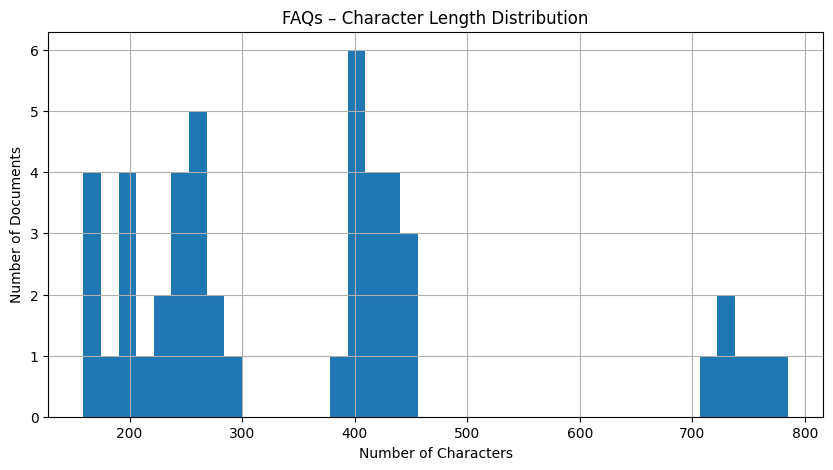


===== FAQS: TOKEN DISTRIBUTION =====
📊 Token Length Stats
count     48.000000
mean      82.125000
std       35.270761
min       45.000000
50%       73.500000
75%       97.250000
90%      152.200000
95%      159.000000
max      167.000000
dtype: float64


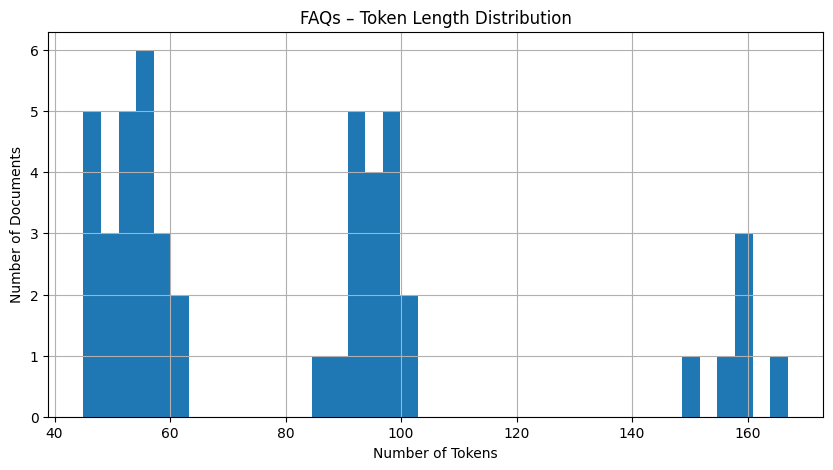


===== HOLDINGS: CHARACTER DISTRIBUTION =====
📊 Character Length Stats
count        6.000000
mean      7799.166667
std       4253.293661
min       2916.000000
50%       8430.000000
75%      11214.250000
90%      12028.000000
95%      12264.500000
max      12501.000000
dtype: float64


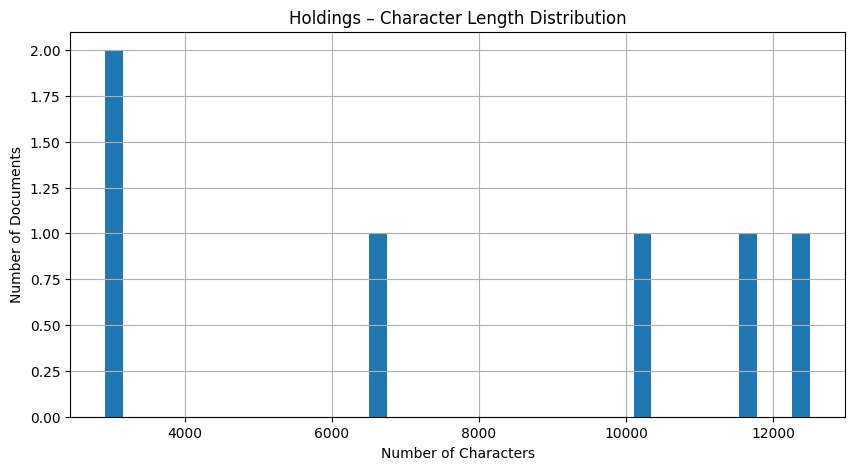


===== HOLDINGS: TOKEN DISTRIBUTION =====


Token indices sequence length is longer than the specified maximum sequence length for this model (3596 > 512). Running this sequence through the model will result in indexing errors


📊 Token Length Stats
count       6.000000
mean     2252.833333
std      1219.594755
min       839.000000
50%      2488.000000
75%      3196.000000
90%      3429.000000
95%      3512.500000
max      3596.000000
dtype: float64


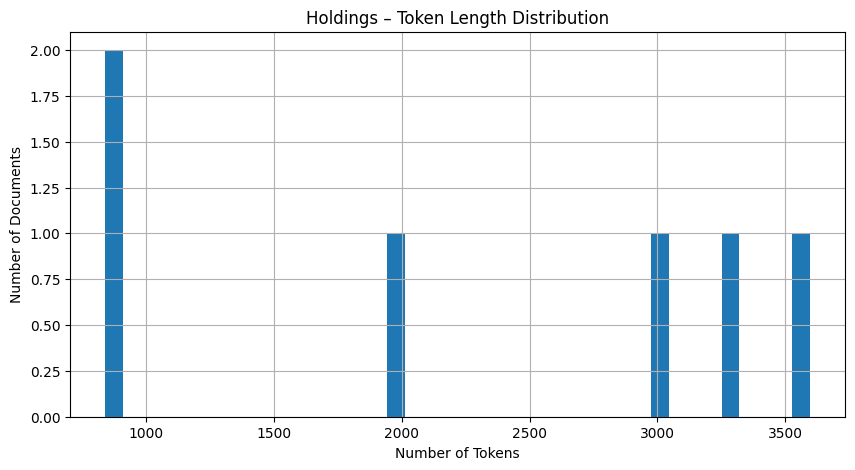

[3596, 844, 839, 1978, 3262, 2998]

In [18]:
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

# Filter sections
faq_docs = filter_documents_by_section(documents, "faqs")
holding_docs = filter_documents_by_section(documents, "holdings")

# ---------- FAQs ----------
print("\n===== FAQS: CHARACTER DISTRIBUTION =====")
plot_document_character_lengths(
    faq_docs,
    title="FAQs – Character Length Distribution"
)

print("\n===== FAQS: TOKEN DISTRIBUTION =====")
plot_document_token_lengths(
    faq_docs,
    EMBEDDING_MODEL_NAME,
    title="FAQs – Token Length Distribution"
)

# ---------- HOLDINGS ----------
print("\n===== HOLDINGS: CHARACTER DISTRIBUTION =====")
plot_document_character_lengths(
    holding_docs,
    title="Holdings – Character Length Distribution"
)

print("\n===== HOLDINGS: TOKEN DISTRIBUTION =====")
plot_document_token_lengths(
    holding_docs,
    EMBEDDING_MODEL_NAME,
    title="Holdings – Token Length Distribution"
)


## Data Driven chunking -

| Section  | Chunk Size (chars) | Overlap | Token Target |
| -------- | ------------------ | ------- | ------------ |
| FAQs     | 800                | 80      | ~200         |
| Holdings | 1000               | 150     | ~250         |


In [19]:
from typing import List
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from transformers import AutoTokenizer

In [20]:
# Embedding model (used only for tokenizer awareness here)
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

# Section-specific chunking parameters (derived from your data)
CHUNKING_CONFIG = {
    "faqs": {
        "chunk_size": 800,
        "chunk_overlap": 80,
    },
    "holdings": {
        "chunk_size": 1000,
        "chunk_overlap": 150,
    }
}

# Sections that should be chunked
SECTIONS_TO_CHUNK = {"faqs", "holdings"}

In [21]:
def build_text_splitter(
    tokenizer_name: str,
    chunk_size: int,
    chunk_overlap: int
) -> RecursiveCharacterTextSplitter:
    """
    Create a token-aware recursive character text splitter.
    """
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    
    splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
        tokenizer=tokenizer,
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
    )
    
    return splitter

In [22]:
def chunk_document(
    document: Document,
    splitter: RecursiveCharacterTextSplitter
) -> List[Document]:
    """
    Split a single document into chunks.
    Metadata is copied exactly from the parent document.
    """
    chunks = splitter.split_text(document.page_content)
    
    return [
        Document(
            page_content=chunk,
            metadata=document.metadata.copy()
        )
        for chunk in chunks
    ]

In [23]:
def chunk_documents_section_wise(
    documents: List[Document]
) -> List[Document]:
    """
    Apply section-specific chunking rules.
    Non-eligible sections are passed through unchanged.
    """
    
    chunked_documents = []
    
    for doc in documents:
        section = doc.metadata.get("section")
        
        # If section is not meant to be chunked, keep as-is
        if section not in SECTIONS_TO_CHUNK:
            chunked_documents.append(doc)
            continue
        
        # Fetch section-specific config
        config = CHUNKING_CONFIG.get(section)
        
        splitter = build_text_splitter(
            tokenizer_name=EMBEDDING_MODEL_NAME,
            chunk_size=config["chunk_size"],
            chunk_overlap=config["chunk_overlap"],
        )
        
        chunks = chunk_document(doc, splitter)
        
        print(
            f"✂️ Chunked section='{section}' | "
            f"Original chars={len(doc.page_content)} | "
            f"Chunks created={len(chunks)}"
        )
        
        chunked_documents.extend(chunks)
    
    print(f"\n✅ Total documents after chunking: {len(chunked_documents)}")
    return chunked_documents

In [24]:
chunked_documents = chunk_documents_section_wise(documents)

Token indices sequence length is longer than the specified maximum sequence length for this model (3583 > 512). Running this sequence through the model will result in indexing errors


✂️ Chunked section='holdings' | Original chars=12501 | Chunks created=6
✂️ Chunked section='faqs' | Original chars=725 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=256 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=403 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=205 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=398 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=245 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=162 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=423 | Chunks created=1


Token indices sequence length is longer than the specified maximum sequence length for this model (833 > 512). Running this sequence through the model will result in indexing errors


✂️ Chunked section='holdings' | Original chars=2963 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=713 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=250 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=394 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=196 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=392 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=239 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=159 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=429 | Chunks created=1


Token indices sequence length is longer than the specified maximum sequence length for this model (824 > 512). Running this sequence through the model will result in indexing errors


...

✂️ Chunked section='holdings' | Original chars=6668 | Chunks created=4
✂️ Chunked section='faqs' | Original chars=765 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=276 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=433 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=222 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=418 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=265 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=182 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=443 | Chunks created=1


Token indices sequence length is longer than the specified maximum sequence length for this model (3249 > 512). Running this sequence through the model will result in indexing errors


✂️ Chunked section='holdings' | Original chars=11555 | Chunks created=5
✂️ Chunked section='faqs' | Original chars=725 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=256 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=403 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=202 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=398 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=245 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=162 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=435 | Chunks created=1


Token indices sequence length is longer than the specified maximum sequence length for this model (2985 > 512). Running this sequence through the model will result in indexing errors


✂️ Chunked section='holdings' | Original chars=10192 | Chunks created=5
✂️ Chunked section='faqs' | Original chars=785 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=286 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=448 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=232 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=428 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=275 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=192 | Chunks created=1
✂️ Chunked section='faqs' | Original chars=445 | Chunks created=1

✅ Total documents after chunking: 172


In [25]:
print("\n📄 Sample Chunk Content:\n")
print(chunked_documents[0].page_content[:1000])

print("\n🧾 Sample Chunk Metadata:\n")
print(chunked_documents[0].metadata)


📄 Sample Chunk Content:

Scheme Overview:
Parag Parikh Flexi Cap Fund Direct Growth

Category: Equity
Sub-category: Flexi Cap
Risk Level: Very High Risk

NAV: ₹95.00 (as on 26 Nov 2025)
Rating: 5
Minimum SIP Amount: ₹1,000
Fund Size: ₹1,25,799.63Cr

🧾 Sample Chunk Metadata:

{'scheme_id': 'parag-parikh-long-term-value-fund-direct-growth', 'scheme_name': 'Parag Parikh Flexi Cap Fund Direct Growth', 'amc_name': 'Parag Parikh Mutual Fund', 'category': 'Equity', 'sub_category': 'Flexi Cap', 'risk': 'Very High Risk', 'source_url': 'https://groww.in/mutual-funds/parag-parikh-long-term-value-fund-direct-growth', 'data_source': 'groww', 'ingest_type': 'structured_json', 'section': 'overview', 'content_type': 'summary'}


In [26]:
CHUNKED_DOCS_DIR = r"E:\ML Projects\RAG_Chatbot_PP_MF\0-DataIngestParsing\data\chunked_documents"

save_documents_to_disk(chunked_documents, CHUNKED_DOCS_DIR)

💾 Saved 6 documents → E:\ML Projects\RAG_Chatbot_PP_MF\0-DataIngestParsing\data\chunked_documents\overview\overview.jsonl
💾 Saved 22 documents → E:\ML Projects\RAG_Chatbot_PP_MF\0-DataIngestParsing\data\chunked_documents\holdings\holdings.jsonl
💾 Saved 6 documents → E:\ML Projects\RAG_Chatbot_PP_MF\0-DataIngestParsing\data\chunked_documents\advanced_ratios\advanced_ratios.jsonl
💾 Saved 72 documents → E:\ML Projects\RAG_Chatbot_PP_MF\0-DataIngestParsing\data\chunked_documents\returns_and_rankings\returns_and_rankings.jsonl
💾 Saved 18 documents → E:\ML Projects\RAG_Chatbot_PP_MF\0-DataIngestParsing\data\chunked_documents\fund_management\fund_management.jsonl
💾 Saved 48 documents → E:\ML Projects\RAG_Chatbot_PP_MF\0-DataIngestParsing\data\chunked_documents\faqs\faqs.jsonl


In [29]:

chunked_docs_loaded = load_documents_from_disk(CHUNKED_DOCS_DIR)


📥 Loaded 172 documents from E:\ML Projects\RAG_Chatbot_PP_MF\0-DataIngestParsing\data\chunked_documents
